## MECHA

### Computing the root hydraulic properties

MECHA is an explicit cross-section model of the root hydraulic anatomy which connects hydraulic concepts across scales.

### Run MECHA


In [1]:
%cd ..

/mnt/c/Users/heymansad/OneDrive - UCL/Documents/GitHub/HydroNeedle/MECHA-dev


In [1]:
from mecha.utils.data_loader import *

In [3]:
AllIn = InData(cellset_file="inputs/current_root.xml")

AllIn.info()

Setting default boundary conditions...

=== InData Configuration Summary ===

File Paths:
  Boundary file: Using defaults
  General file: Using defaults
  Geometry file: Using defaults
  Hormones file: Using defaults
  Hydraulics file: Using defaults
  Cellset file: inputs/current_root.xml

Boundary Configuration:
  Number of scenarios: 1
  Solute transport flag: False
  Scenarios:
    Scenario 1:
      psi_soil_left: 0.0
      psi_soil_right: 0.0
      osmotic_left_soil: 0.0
      osmotic_right_soil: 0.0
      osmotic_symmetry_soil: 1.0
      osmotic_shape_soil: 1.0
      osmotic_diffusivity_soil: 0.0
      osmotic_xyl: 0.0
      osmotic_endo: 0.0
      osmotic_symmetry_xyl: 1.0
      osmotic_shape_xyl: 1.0
      osmotic_diffusivity_xyl: 0.0
      pressure_xyl_prox: -5000.0
      pressure_xyl_dist: nan
      flow_xyl_prox: nan
      flow_xyl_dist: nan
      delta_p_xyl_prox: nan
      pressure_sieve_prox: 11000.0
      pressure_sieve_dist: nan
      flow_sieve_prox: nan
      flow_sie

### Preview section


In [4]:
from mecha.utils.visu import *

visualize(AllIn.cellset_data, "polygon")


NameError: name 'visualize' is not defined

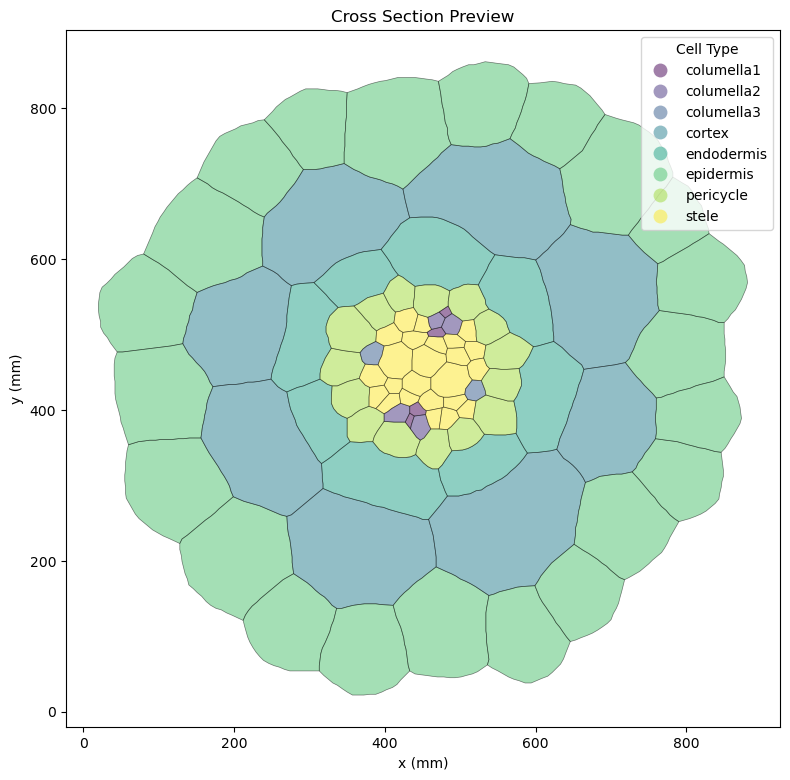

In [6]:
Arabidopsis = parse_cellset("./tutorials/tutorial_data/Arabidopsis.xml")
visualize(Arabidopsis, "polygon")

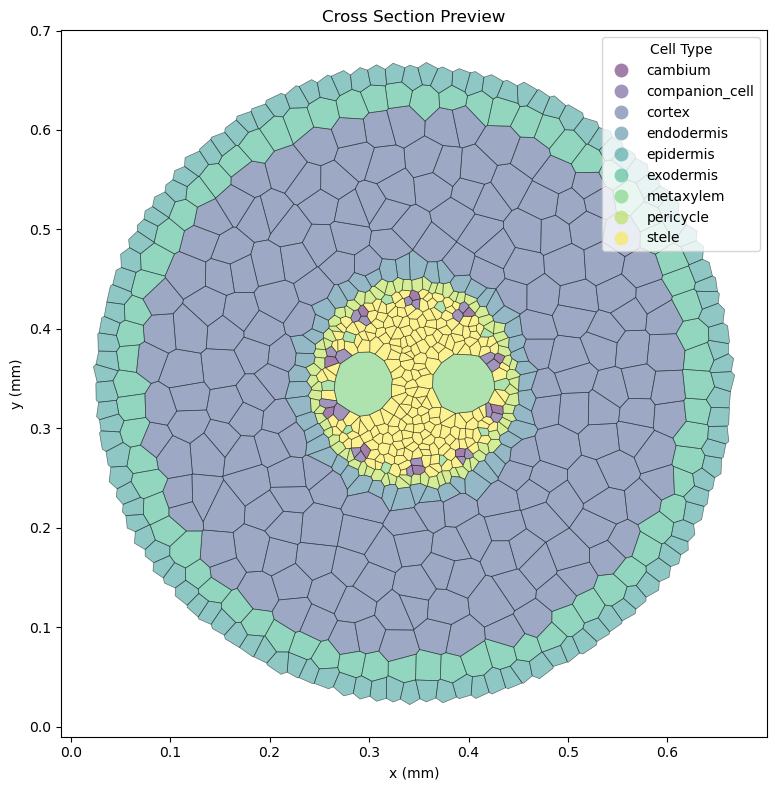

In [6]:
sorghum = parse_cellset("./tutorials/tutorial_data/sorghum_7cm.xml")
visualize(sorghum, "polygon")

In [7]:
from src.utils.network_builder import *
import networkx as nx

section_nx = NetworkBuilder()
section_nx.build_network(AllIn.general, AllIn.geometry, Arabidopsis)

position=nx.get_node_attributes(section_nx.graph,'position') #Updates nodes XY positions (micrometers)
indice=nx.get_node_attributes(section_nx.graph,'indice') #Node indices (walls, junctions and cells)

  Creating wall, junction and cell nodes...
  Creating membrane connections...
  Ranking cells by tissue type and distance from root center...


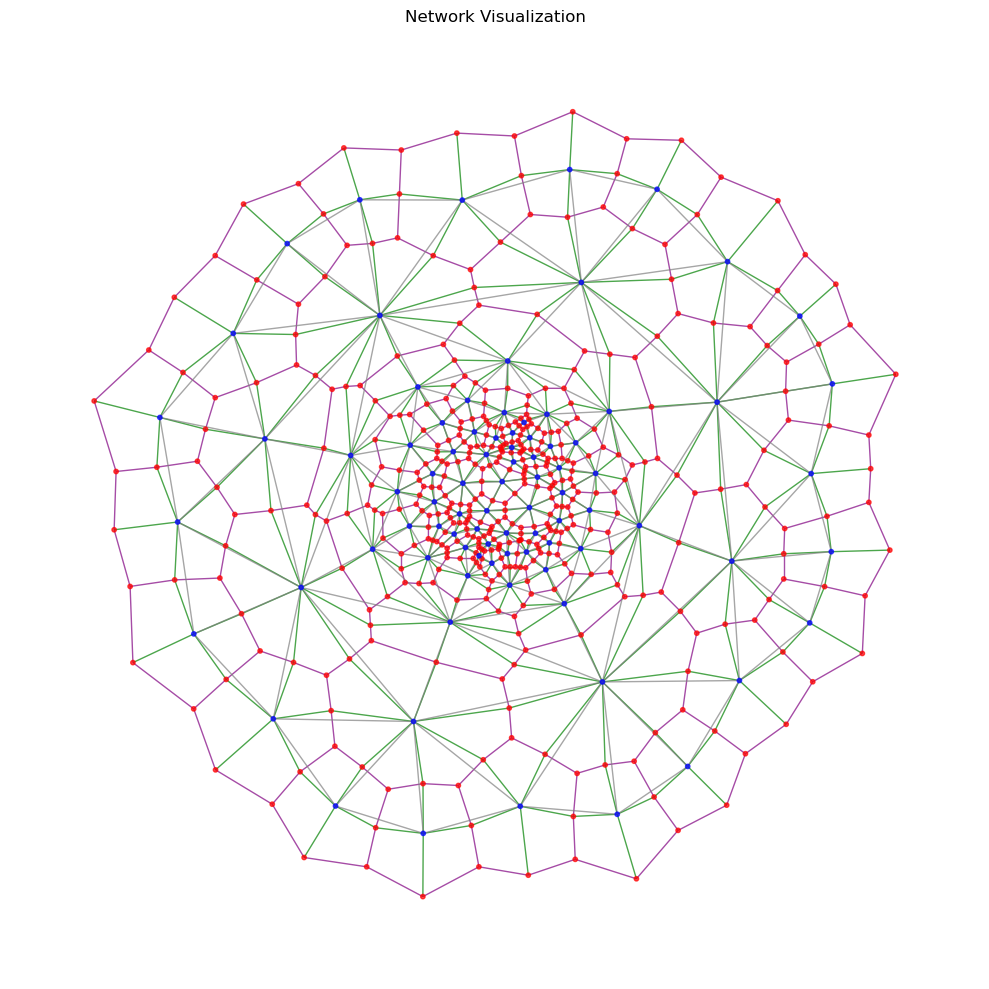

In [8]:
visualize(section_nx, "network")

In [7]:
print(AllIn.geometry.n_maturity)
print(AllIn.boundary.n_scenarios)

section_nx.r_discret

AllIn.hydraulic.kw_elems

1
1


[{'value': 0.00024}]

In [2]:
from importlib import reload

import src.mecha_class
import src.utils.data_loader
import src.utils.network_builder
import src.utils.visu

reload(src.mecha_class)
reload(src.utils.data_loader)
reload(src.utils.network_builder)
reload(src.utils.visu)

from src.mecha_class import Mecha
from src.utils.data_loader import *
from src.utils.network_builder import *
from src.utils.visu import *


AllIn = InData(cellset_file="extdata/current_root.xml")

AllIn.geometry.set_maturity_stages([1,3])

Setting default boundary conditions...
barrier and height must have the same length


In [3]:
scenario_1 = {
            'psi_soil_left': 0.0,
            'psi_soil_right': 0.0,
            'osmotic_left_soil': 0.0,
            'osmotic_right_soil': 0.0,
            'osmotic_symmetry_soil': 1.0,
            'osmotic_shape_soil': 1.0,
            'osmotic_diffusivity_soil': 0.0,
            'osmotic_xyl': 0.0,
            'osmotic_endo': 0.0,
            'osmotic_symmetry_xyl': 1.0,
            'osmotic_shape_xyl': 1.0,
            'osmotic_diffusivity_xyl': 0.0,
            'pressure_xyl_prox': -5.0E3,
            'pressure_xyl_dist': np.nan,
            'flow_xyl_prox': np.nan,
            'flow_xyl_dist': np.nan,
            'delta_p_xyl_prox': np.nan,
            'pressure_sieve_prox': 1.1E4,
            'pressure_sieve_dist': np.nan,
            'flow_sieve_prox': np.nan,
            'flow_sieve_dist': np.nan,
            'delta_p_sieve': np.nan,
            'osmotic_sieve': np.nan,
            's_hetero': 0,
            's_factor': 1.0,
            'os_hetero': 0,
            'os_cortex': 0.0,
            'elongation_midpoint_rate': 2.8,
            'elongation_side_rate_difference': 0.0,
        }

AllIn.boundary.add_scenario(scenario_1)
section_maize = Mecha(AllIn)
_, _ = section_maize.water_flux(h=0)

Solving system
4.997312113000135 seconds process time to solve system
Solving system
4.698613999999907 seconds process time to solve system
Solving system
3.995838418999938 seconds process time to solve system
Solving system
3.8184681210000235 seconds process time to solve system


In [29]:
res = section_maize.results[0]["rhs"]
np.unique(res[~np.isnan(res)])

array([0.])

In [24]:
for i, val in enumerate(res):
    psi = val[0]
    if psi is not np.nan:
        pass
    else:
        print(i," " ,psi)

KeyError: 0

DEBUG: MatrixW (dense) stats - NaNs: 0, Min: -0.0008436912058746876, Max: 0.00028117176551642394
DEBUG: Error retrieving pot for cid 0 at idx 8432
DEBUG: Error retrieving pot for cid 1 at idx 8433
DEBUG: Error retrieving pot for cid 2 at idx 8434
DEBUG: Error retrieving pot for cid 3 at idx 8435
DEBUG: Error retrieving pot for cid 4 at idx 8436
DEBUG: Error retrieving pot for cid 5 at idx 8437
DEBUG: Error retrieving pot for cid 6 at idx 8438
DEBUG: Error retrieving pot for cid 7 at idx 8439
DEBUG: Error retrieving pot for cid 8 at idx 8440
DEBUG: Error retrieving pot for cid 9 at idx 8441
DEBUG: Error retrieving pot for cid 10 at idx 8442
DEBUG: Error retrieving pot for cid 11 at idx 8443
DEBUG: Error retrieving pot for cid 12 at idx 8444
DEBUG: Error retrieving pot for cid 13 at idx 8445
DEBUG: Error retrieving pot for cid 14 at idx 8446
DEBUG: Error retrieving pot for cid 15 at idx 8447
DEBUG: Error retrieving pot for cid 16 at idx 8448
DEBUG: Error retrieving pot for cid 17 at idx 

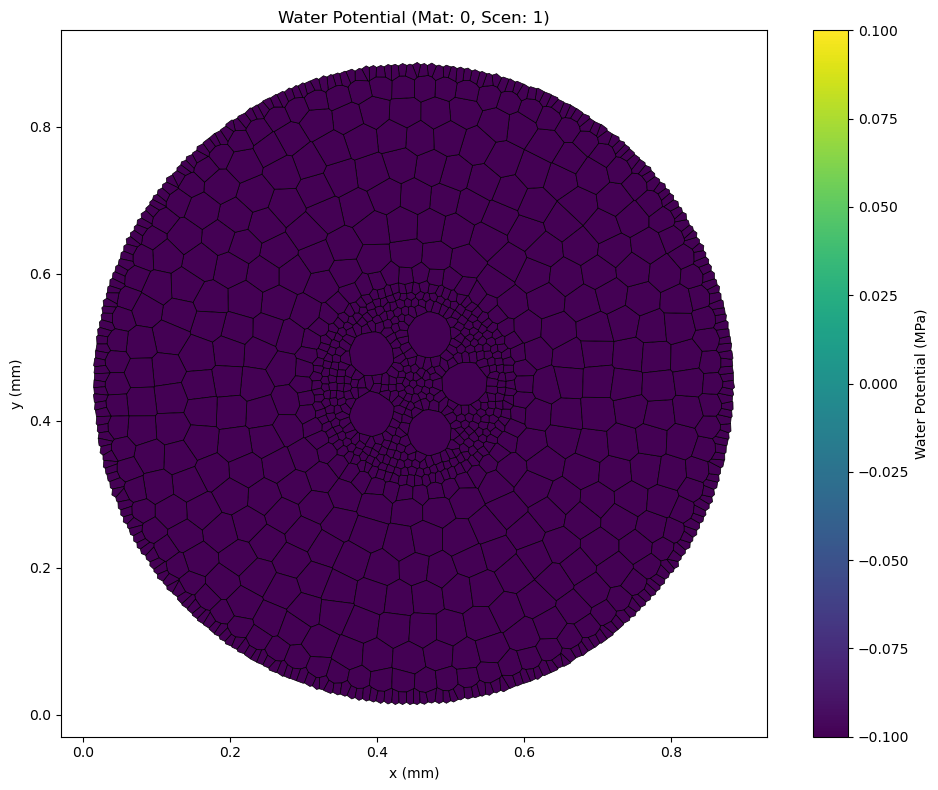

In [4]:
to_plot = {'maturity_idx':0, 'scenario_idx':1}
visualize(section_maize, "water_potential", **to_plot)

In [26]:
print(section_maize.stf_cell_minus[:][0])
print(section_maize.stf_cell_plus[:][0])

[-3.54637525e-07 -2.36511315e-07]
[3.47111365e-07 2.30763108e-07]


In [4]:
section_maize = Mecha(AllIn)
section_maize.compute_conductivities()

Solving system
3.771126996000021 seconds process time to solve system
Solving system
3.6065633169999955 seconds process time to solve system


In [5]:
for i in range(len(section_maize.root_hydraulic_properties)):
    print(section_maize.root_hydraulic_properties[i])

{'barrier': 1, 'height': 200.0, 'kr': 9.126796655017295e-05, 'Kx': 1.3416058586221151}
{'barrier': 3, 'height': 200.0, 'kr': 3.5783996213830456e-05, 'Kx': 1.3416058586221151}


In [31]:
section_maize.edge_flux_list[0][1]

[]

In [6]:
section_maize.kr_tot

array([[9.12679666e-05],
       [3.57839962e-05]])

In [11]:
visualize(section_maize.bc, "osmotic_pot")

section_maize.solve()


kr_1 = section_maize.kr[0]
kr_3 = section_maize.kr[1]

visualize(section_maize.solution[0], "wall")

visualize(section_maize.partition[0])

NameError: name 'mecha' is not defined

In [12]:
info = {'STUF' : Hydr.STFlayer_plus,
        'STRF' : Hydr.STFlayer_minus, 
        'dist' : Hydr.Layer_dist2,
        'type' : Hydr.cell_type}
df = pd.DataFrame(data = info)
df = df[::-1].reset_index(drop=True)
df['STF diff'] = df['STUF']-df['STRF']
df['STF'] = df['STF diff'].cumsum()
df['cell_spacing'] = df['dist'].diff()

poly = Macro_hydro_visu.poly_table(df)
Macro_hydro_visu.graph_apo_symp(poly)

NameError: name 'Hydr' is not defined

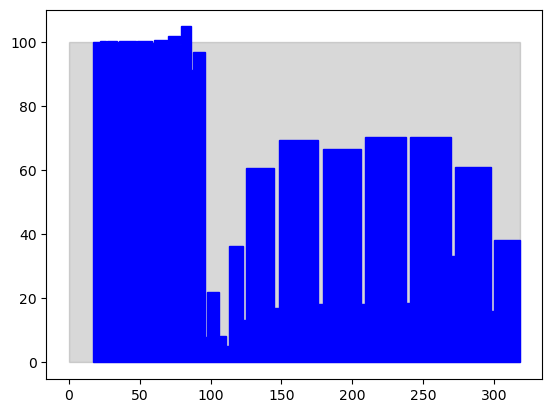

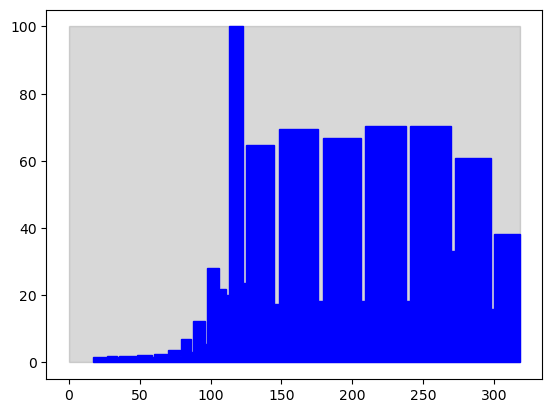

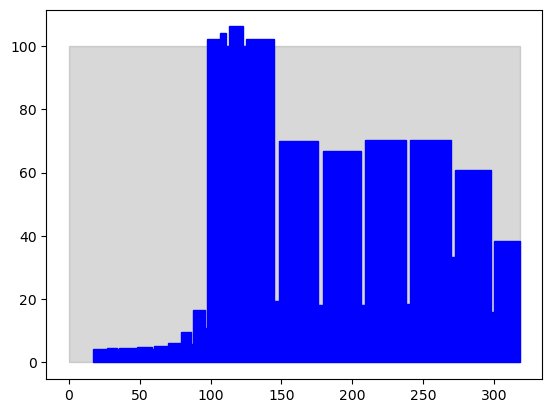

In [13]:
# Set the folder path where the .txt files are located
folder_path = os.path.join(dir, Project, "out/Tomato/Root/Project_Test/results/")

# Loop through all .txt files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt") & file_name.startswith("Macro_prop"):  # Check if the Macro_prop file is a .txt file
        file_path = os.path.join(folder_path, file_name)  # Full path to the file
        
        # Open and read the file
        with open(file_path, "r") as file:
            # Read the contents of the file
            fl = file.read()
        
        # Call your plot function with the file content
        plot_partition(fl)

In [19]:
#Project
Project ='Projects/maize_granar/' 

# Run MECHA
MECHA_run(dir, Project)

Importing Data
0.5602447110004505 seconds process time
Initializing network
Identifying soil-root interface walls
Getting X and Y cell nodes
0.6448194920003516 seconds process time
Creating network connections
12.978253702000075 seconds process time
Computing cortex AQP parameters
0.08688259400059906 seconds process time
Maturity #0 with apoplastic barrier type #1
Maturity #1 with apoplastic barrier type #2
Maturity #2 with apoplastic barrier type #4
4.065473115999339 seconds process time


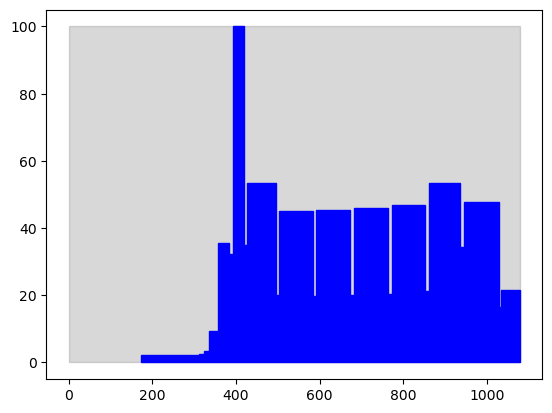

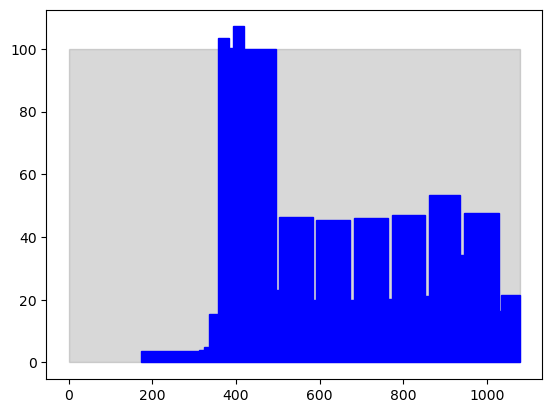

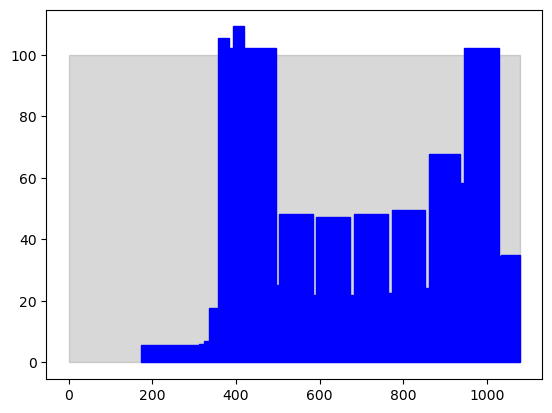

In [17]:
# Set the folder path where the .txt files are located
folder_path = os.path.join(dir, Project, "out/M1v4/Root/Project_Test/results/")

# Loop through all .txt files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt") & file_name.startswith("Macro_prop"):  # Check if the Macro_prop file is a .txt file
        file_path = os.path.join(folder_path, file_name)  # Full path to the file
        
        # Open and read the file
        with open(file_path, "r") as file:
            # Read the contents of the file
            fl = file.read()
        
        # Call your plot function with the file content
        plot_partition(fl)